In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Load the dataset ───
from google.colab import drive
drive.mount('/content/drive')

root_path = '/content/drive/MyDrive/'


print('Loading dataset...')
df = pd.read_csv(root_path + 'car_insurance_claim.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nData Info:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display basic statistics
print("\nNumerical Features Statistics:")
print(df.describe())

Mounted at /content/drive
Loading dataset...
Dataset Shape: (10302, 27)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  object 
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   object 
 7   PARENT1     10302 non-null  object 
 8   HOME_VAL    9727 non-null   object 
 9   MSTATUS     10302 non-null  object 
 10  GENDER      10302 non-null  object 
 11  EDUCATION   10302 non-null  object 
 12  OCCUPATION  9637 non-null   object 
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  object 
 15  BLUEBOOK    10302 non-null  object 
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-n

In [3]:
# ─── Diagnostic complémentaire ───
# Vérifier CAR_AGE négatif
print("CAR_AGE négatifs:", (df['CAR_AGE'] < 0).sum())
print("\nValeurs uniques des colonnes catégorielles clés:")
for col in ['MSTATUS', 'GENDER', 'EDUCATION', 'OCCUPATION', 'URBANICITY', 'CAR_TYPE']:
    print(f"  {col}: {df[col].unique()}")

print("\nDistribution CLAIM_FLAG:")
print(df['CLAIM_FLAG'].value_counts(normalize=True))

# Vérifier la fuite supposée de CLM_AMT
print("\nCLM_AMT vs CLAIM_FLAG (vérification fuite de cible):")
clm_amt_numeric = df['CLM_AMT'].str.replace('[$,]', '', regex=True).astype(float)
print(f"  CLM_AMT > 0 quand CLAIM_FLAG=0 : {((clm_amt_numeric > 0) & (df['CLAIM_FLAG']==0)).sum()} lignes")
print(f"  CLM_AMT > 0 quand CLAIM_FLAG=1 : {((clm_amt_numeric > 0) & (df['CLAIM_FLAG']==1)).sum()} lignes")

CAR_AGE négatifs: 1

Valeurs uniques des colonnes catégorielles clés:
  MSTATUS: ['z_No' 'Yes']
  GENDER: ['M' 'z_F']
  EDUCATION: ['PhD' 'z_High School' 'Bachelors' '<High School' 'Masters']
  OCCUPATION: ['Professional' 'z_Blue Collar' 'Manager' 'Clerical' 'Doctor' 'Lawyer' nan
 'Home Maker' 'Student']
  URBANICITY: ['Highly Urban/ Urban' 'z_Highly Rural/ Rural']
  CAR_TYPE: ['Minivan' 'Van' 'z_SUV' 'Sports Car' 'Panel Truck' 'Pickup']

Distribution CLAIM_FLAG:
CLAIM_FLAG
0    0.73345
1    0.26655
Name: proportion, dtype: float64

CLM_AMT vs CLAIM_FLAG (vérification fuite de cible):
  CLM_AMT > 0 quand CLAIM_FLAG=0 : 0 lignes
  CLM_AMT > 0 quand CLAIM_FLAG=1 : 2746 lignes


In [4]:
# ─── Nettoyage ───
df_clean = df.copy()

# 1. Colonnes à supprimer
#    - ID : identifiant, sans valeur prédictive
#    - BIRTH : redondant avec AGE
#    - CLM_AMT : fuite de cible (vaut 0 ssi CLAIM_FLAG=0)
df_clean = df_clean.drop(columns=['ID', 'BIRTH', 'CLM_AMT'])

# 2. Parser les colonnes monétaires : "$67,349 " → 67349.0
money_cols = ['INCOME', 'HOME_VAL', 'BLUEBOOK', 'OLDCLAIM']
for col in money_cols:
    df_clean[col] = (
        df_clean[col]
        .str.replace('[$,\s]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

# 3. Nettoyer les préfixes z_ (artefact SAS)
def strip_z(value):
    if isinstance(value, str) and value.startswith('z_'):
        return value[2:]
    return value

cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = df_clean[col].apply(strip_z)

# Cas spécial URBANICITY : "Highly Rural/ Rural" et "Highly Urban/ Urban"
# On simplifie en binaire pour la lisibilité
df_clean['URBANICITY'] = df_clean['URBANICITY'].apply(
    lambda x: 'Urban' if 'Urban' in x else 'Rural'
)

# 4. CAR_AGE négatif → NaN (à imputer ensuite)
df_clean.loc[df_clean['CAR_AGE'] < 0, 'CAR_AGE'] = np.nan

# 5. Vérification
print("Shape après nettoyage:", df_clean.shape)
print("\nTypes après parsing:")
print(df_clean.dtypes)
print("\nValeurs manquantes après nettoyage:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nAperçu:")
df_clean.head()

Shape après nettoyage: (10302, 24)

Types après parsing:
KIDSDRIV        int64
AGE           float64
HOMEKIDS        int64
YOJ           float64
INCOME        float64
PARENT1        object
HOME_VAL      float64
MSTATUS        object
GENDER         object
EDUCATION      object
OCCUPATION     object
TRAVTIME        int64
CAR_USE        object
BLUEBOOK      float64
TIF             int64
CAR_TYPE       object
RED_CAR        object
OLDCLAIM      float64
CLM_FREQ        int64
REVOKED        object
MVR_PTS         int64
CAR_AGE       float64
CLAIM_FLAG      int64
URBANICITY     object
dtype: object

Valeurs manquantes après nettoyage:
AGE             7
YOJ           548
INCOME        570
HOME_VAL      575
OCCUPATION    665
CAR_AGE       640
dtype: int64

Aperçu:


<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11869/1778984384.py:15: SyntaxWarning: invalid escape sequence '\s'
  .str.replace('[$,\s]', '', regex=True)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,CLAIM_FLAG,URBANICITY
0,0,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,...,11,Minivan,yes,4461.0,2,No,3,18.0,0,Urban
1,0,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,...,1,Minivan,yes,0.0,0,No,0,1.0,0,Urban
2,0,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,...,1,Van,yes,0.0,0,No,2,10.0,0,Urban
3,0,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,...,4,SUV,no,38690.0,2,No,3,10.0,0,Urban
4,0,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,...,7,Minivan,yes,0.0,0,No,0,6.0,0,Urban


Taux de sinistre par GENDER:
            mean  count
GENDER                 
F       0.275564   5545
M       0.256044   4757 

Taux de sinistre par URBANICITY:
                mean  count
URBANICITY                 
Rural       0.064672   2072
Urban       0.317375   8230 

Taux de sinistre par tranche d'âge:
             mean  count
AGE_BIN                 
16-25    0.650000    120
26-35    0.362538   1324
36-45    0.279919   3944
46-55    0.195276   3810
56-65    0.309500   1021
66+      0.236842     76 

Croisement GENDER × URBANICITY:
URBANICITY     Rural     Urban
GENDER                        
F           0.061157  0.335409
M           0.069606  0.297304 

Taux de sinistre par EDUCATION:
EDUCATION
<High School    0.324752
High School     0.346545
Bachelors       0.238399
Masters         0.194418
PhD             0.164882
Name: CLAIM_FLAG, dtype: float64 



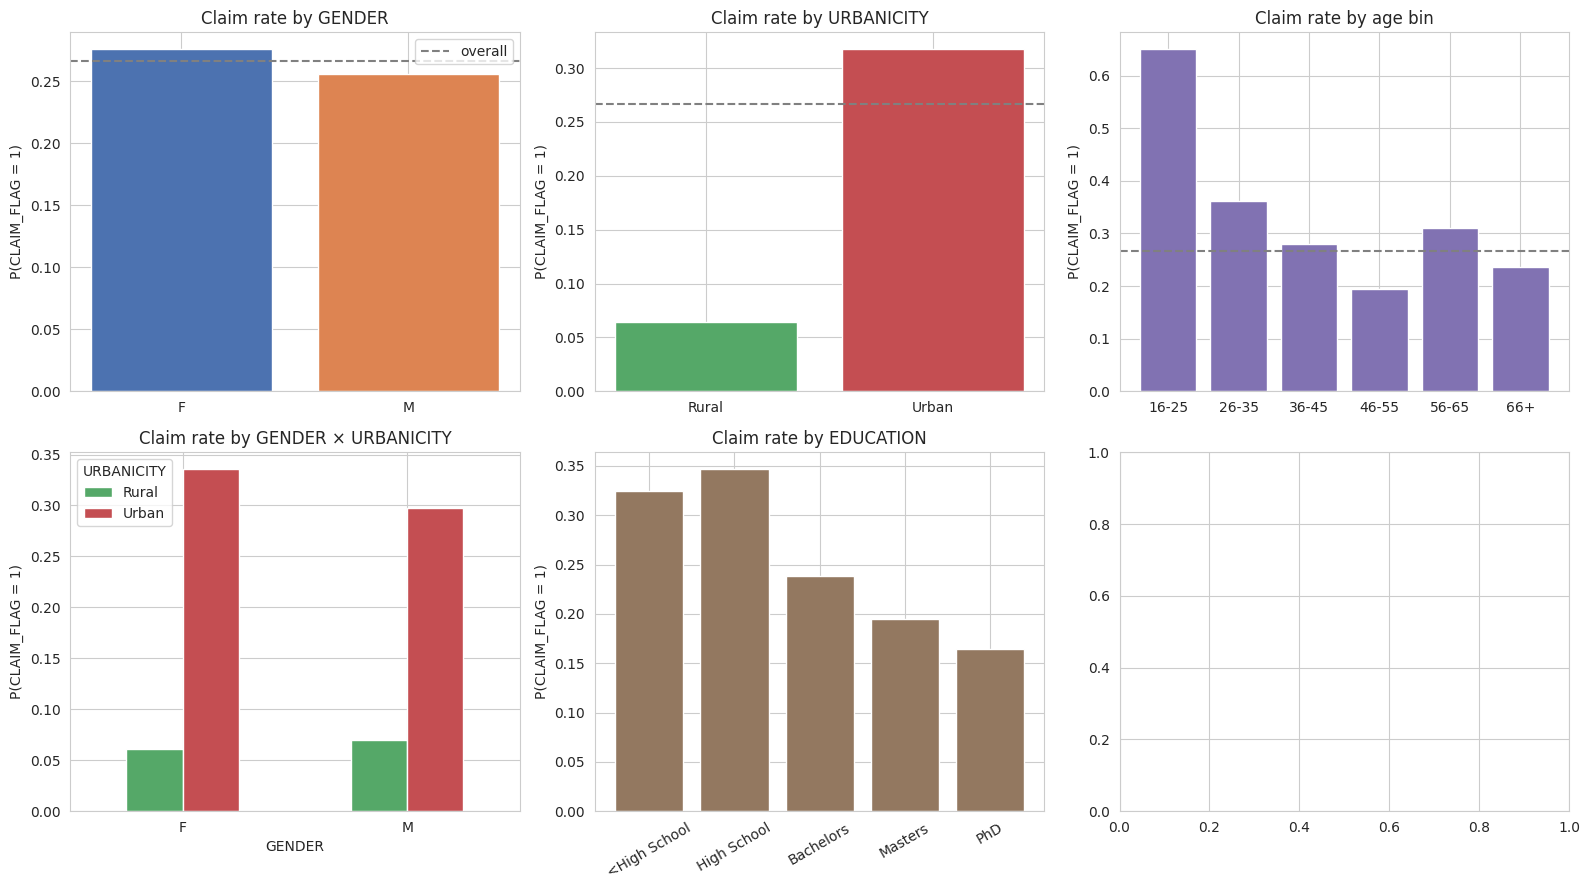

In [5]:
# ─── EDA orientée fairness ───
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- (1) Taux de sinistre par GENDER ---
gender_rate = df_clean.groupby('GENDER')['CLAIM_FLAG'].agg(['mean', 'count'])
print("Taux de sinistre par GENDER:")
print(gender_rate, "\n")

axes[0, 0].bar(gender_rate.index, gender_rate['mean'], color=['#4C72B0', '#DD8452'])
axes[0, 0].set_title('Claim rate by GENDER')
axes[0, 0].set_ylabel('P(CLAIM_FLAG = 1)')
axes[0, 0].axhline(df_clean['CLAIM_FLAG'].mean(), ls='--', color='gray', label='overall')
axes[0, 0].legend()

# --- (2) Taux de sinistre par URBANICITY ---
urban_rate = df_clean.groupby('URBANICITY')['CLAIM_FLAG'].agg(['mean', 'count'])
print("Taux de sinistre par URBANICITY:")
print(urban_rate, "\n")

axes[0, 1].bar(urban_rate.index, urban_rate['mean'], color=['#55A868', '#C44E52'])
axes[0, 1].set_title('Claim rate by URBANICITY')
axes[0, 1].set_ylabel('P(CLAIM_FLAG = 1)')
axes[0, 1].axhline(df_clean['CLAIM_FLAG'].mean(), ls='--', color='gray')

# --- (3) Taux de sinistre par tranche d'âge ---
df_clean['AGE_BIN'] = pd.cut(df_clean['AGE'], bins=[15, 25, 35, 45, 55, 65, 85],
                              labels=['16-25', '26-35', '36-45', '46-55', '56-65', '66+'])
age_rate = df_clean.groupby('AGE_BIN', observed=True)['CLAIM_FLAG'].agg(['mean', 'count'])
print("Taux de sinistre par tranche d'âge:")
print(age_rate, "\n")

axes[0, 2].bar(age_rate.index.astype(str), age_rate['mean'], color='#8172B2')
axes[0, 2].set_title('Claim rate by age bin')
axes[0, 2].set_ylabel('P(CLAIM_FLAG = 1)')
axes[0, 2].axhline(df_clean['CLAIM_FLAG'].mean(), ls='--', color='gray')

# --- (4) Croisement GENDER × URBANICITY ---
cross = df_clean.groupby(['GENDER', 'URBANICITY'])['CLAIM_FLAG'].mean().unstack()
print("Croisement GENDER × URBANICITY:")
print(cross, "\n")

cross.plot(kind='bar', ax=axes[1, 0], color=['#55A868', '#C44E52'])
axes[1, 0].set_title('Claim rate by GENDER × URBANICITY')
axes[1, 0].set_ylabel('P(CLAIM_FLAG = 1)')
axes[1, 0].tick_params(axis='x', rotation=0)

# --- (5) Taux par EDUCATION (proxy socio-éco) ---
edu_order = ['<High School', 'High School', 'Bachelors', 'Masters', 'PhD']
edu_rate = df_clean.groupby('EDUCATION')['CLAIM_FLAG'].mean().reindex(edu_order)
print("Taux de sinistre par EDUCATION:")
print(edu_rate, "\n")

axes[1, 1].bar(edu_rate.index, edu_rate.values, color='#937860')
axes[1, 1].set_title('Claim rate by EDUCATION')
axes[1, 1].set_ylabel('P(CLAIM_FLAG = 1)')
axes[1, 1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.savefig('eda_fairness_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ─── Imputation + définition des features ───
from sklearn.model_selection import train_test_split

df_model = df_clean.drop(columns=['AGE_BIN']).copy()  # on retire le bin créé pour l'EDA

# 1. Imputation simple
#    - numérique : médiane
#    - catégoriel : "Unknown" comme catégorie
num_cols = ['AGE', 'YOJ', 'INCOME', 'HOME_VAL', 'CAR_AGE']
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model['OCCUPATION'] = df_model['OCCUPATION'].fillna('Unknown')

# Vérification : plus aucun NaN
assert df_model.isnull().sum().sum() == 0, "Il reste des NaN !"
print("Aucun NaN après imputation.")

# 2. Séparation X / y
y = df_model['CLAIM_FLAG']
X = df_model.drop(columns=['CLAIM_FLAG'])

# 3. Liste des catégorielles vs numériques (utile pour DiCE plus tard)
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(exclude='object').columns.tolist()

print(f"\nFeatures catégorielles ({len(categorical_features)}):", categorical_features)
print(f"Features numériques ({len(numerical_features)}):", numerical_features)

# 4. Train/test split stratifié sur y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train claim rate: {y_train.mean():.3f}")
print(f"Test claim rate:  {y_test.mean():.3f}")

Aucun NaN après imputation.

Features catégorielles (10): ['PARENT1', 'MSTATUS', 'GENDER', 'EDUCATION', 'OCCUPATION', 'CAR_USE', 'CAR_TYPE', 'RED_CAR', 'REVOKED', 'URBANICITY']
Features numériques (13): ['KIDSDRIV', 'AGE', 'HOMEKIDS', 'YOJ', 'INCOME', 'HOME_VAL', 'TRAVTIME', 'BLUEBOOK', 'TIF', 'OLDCLAIM', 'CLM_FREQ', 'MVR_PTS', 'CAR_AGE']

Train: (8241, 23), Test: (2061, 23)
Train claim rate: 0.267
Test claim rate:  0.266


In [7]:
# ─── Entraînement du modèle + évaluation globale et par sous-groupe ───
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             confusion_matrix)

# 1. Preprocessing : OneHot pour catégorielles, StandardScaler pour numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                 categorical_features)
    ]
)

# 2. Deux modèles : RandomForest et XGBoost
#    Pour gérer le déséquilibre 73/27 :
#      - RF : class_weight='balanced'
#      - XGB : scale_pos_weight = n_neg / n_pos
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos = n_neg / n_pos
print(f"scale_pos_weight pour XGBoost: {scale_pos:.3f}")

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
}

results = {}
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([('preproc', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred),
    }
    fitted_pipelines[name] = pipe

    print(f"\n=== {name} ===")
    print(f"  Accuracy : {results[name]['accuracy']:.3f}")
    print(f"  AUC      : {results[name]['auc']:.3f}")
    print(f"  F1       : {results[name]['f1']:.3f}")

# 3. Tableau récap
print("\n" + "="*50)
print("Récap performances globales:")
print(pd.DataFrame(results).T.round(3))


# 4. Performance par sous-groupe sur les deux modèles
def subgroup_metrics(X, y_true, y_pred, group_col):
    rows = []
    for group_val in sorted(X[group_col].unique()):
        mask = X[group_col] == group_val
        y_t, y_p = y_true[mask], y_pred[mask]
        if len(y_t) == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
        rows.append({
            'group': f"{group_col}={group_val}",
            'n': len(y_t),
            'base_rate': round(y_t.mean(), 3),
            'predicted_rate': round(y_p.mean(), 3),
            'accuracy': round(accuracy_score(y_t, y_p), 3),
            'TPR (recall+)': round(tp / (tp + fn), 3) if (tp + fn) > 0 else np.nan,
            'FPR': round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
        })
    return pd.DataFrame(rows)

print("\n" + "="*50)
print("Performance par sous-groupe:")
print("="*50)

for model_name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f"\n--- {model_name} ---")
    for col in ['GENDER', 'URBANICITY']:
        print(f"\n  By {col}:")
        print(subgroup_metrics(X_test, y_test, y_pred, col).to_string(index=False))

scale_pos_weight pour XGBoost: 2.751

=== RandomForest ===
  Accuracy : 0.780
  AUC      : 0.820
  F1       : 0.599

=== XGBoost ===
  Accuracy : 0.770
  AUC      : 0.815
  F1       : 0.589

Récap performances globales:
              accuracy    auc     f1
RandomForest      0.78  0.820  0.599
XGBoost           0.77  0.815  0.589

Performance par sous-groupe:

--- RandomForest ---

  By GENDER:
   group    n  base_rate  predicted_rate  accuracy  TPR (recall+)   FPR
GENDER=F 1110      0.268           0.310     0.768          0.644 0.187
GENDER=M  951      0.264           0.251     0.794          0.586 0.131

  By URBANICITY:
           group    n  base_rate  predicted_rate  accuracy  TPR (recall+)   FPR
URBANICITY=Rural  402      0.065           0.005     0.930          0.000 0.005
URBANICITY=Urban 1659      0.315           0.350     0.743          0.648 0.213

--- XGBoost ---

  By GENDER:
   group    n  base_rate  predicted_rate  accuracy  TPR (recall+)   FPR
GENDER=F 1110      0.268  

In [8]:
# ─── Installation (à exécuter une seule fois) ───
!pip install dice-ml --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.6 MB/s eta 0:00:00


In [9]:
# ─── Setup DiCE ───
import dice_ml
from dice_ml import Dice

# DiCE a besoin de l'objet Data avec les features catégorielles et la cible
# On utilise le DataFrame complet (train + target) pour que DiCE connaisse les distributions
df_for_dice = X_train.copy()
df_for_dice['CLAIM_FLAG'] = y_train.values

d = dice_ml.Data(
    dataframe=df_for_dice,
    continuous_features=numerical_features,
    outcome_name='CLAIM_FLAG'
)

# Le modèle DiCE wrapper autour de notre pipeline RF
m = dice_ml.Model(
    model=fitted_pipelines['RandomForest'],
    backend='sklearn',
    model_type='classifier'
)

# Deux explainers : random (= Wachter naïf) et genetic (= avec contraintes)
exp_random  = Dice(d, m, method='random')
exp_genetic = Dice(d, m, method='genetic')

print("DiCE explainers prêts.")

DiCE explainers prêts.


In [10]:
# ─── Sélection des candidats : Urban classés positifs ───
y_pred_rf_test = fitted_pipelines['RandomForest'].predict(X_test)

# Mask : urban + prédit comme à risque
urban_positive_mask = (X_test['URBANICITY'] == 'Urban') & (y_pred_rf_test == 1)
candidates = X_test[urban_positive_mask].copy()
print(f"Candidats pour counterfactuels : {len(candidates)} (Urban + predicted_risk=1)")

# On prend le premier comme test
query_instance = candidates.iloc[[0]]  # double crochet pour garder le DataFrame
print("\nFactual:")
print(query_instance.T)

# Génération avec DiCE random (= Wachter naïf, sans contraintes)
print("\n--- DiCE Random (Wachter-like, no constraints) ---")
cf_random = exp_random.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class=0  # on veut flipper vers low-risk
)
cf_random.visualize_as_dataframe(show_only_changes=True)

Candidats pour counterfactuels : 581 (Urban + predicted_risk=1)

Factual:
                   3078
KIDSDRIV              0
AGE                37.0
HOMEKIDS              0
YOJ                 7.0
INCOME          61790.0
PARENT1              No
HOME_VAL            0.0
MSTATUS              No
GENDER                M
EDUCATION   High School
OCCUPATION  Blue Collar
TRAVTIME             32
CAR_USE      Commercial
BLUEBOOK        21460.0
TIF                   3
CAR_TYPE            Van
RED_CAR              no
OLDCLAIM            0.0
CLM_FREQ              0
REVOKED              No
MVR_PTS               0
CAR_AGE             7.0
URBANICITY        Urban

--- DiCE Random (Wachter-like, no constraints) ---


100%|██████████| 1/1 [00:01<00:00,  1.04s/it]

Query instance (original outcome : 1)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLAIM_FLAG
0,0,37.0,0,7.0,61790.0,No,0.0,No,M,High School,...,3,Van,no,0.0,0,No,0,7.0,Urban,1



Diverse Counterfactual set (new outcome: 0)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLAIM_FLAG
0,-,-,4,-,-,-,586470.2,-,-,-,...,-,-,-,-,-,-,-,-,-,0
1,3,-,-,-,-,-,306117.4,-,-,-,...,-,-,-,-,-,-,-,-,-,0
2,-,-,-,-,-,-,507348.7,-,-,-,...,-,-,-,11483.9,-,-,-,-,-,0


In [11]:
# ─── Définition des contraintes d'actionnabilité ───
# On code ces contraintes selon les règles métier de l'assurance :
# - Variables IMMUABLES : ne peuvent pas être changées par l'individu
# - Variables avec contraintes MONOTONES : direction de changement contrainte
# - Variables libres : peuvent varier dans n'importe quel sens

# Features qu'on interdit complètement de modifier
features_to_vary = [
    # numériques librement modifiables
    'YOJ', 'INCOME', 'HOME_VAL', 'TRAVTIME', 'BLUEBOOK',
    'TIF', 'OLDCLAIM', 'CLM_FREQ', 'MVR_PTS', 'CAR_AGE',
    # catégorielles librement modifiables
    'MSTATUS', 'EDUCATION', 'OCCUPATION', 'CAR_USE', 'CAR_TYPE',
    'RED_CAR', 'REVOKED',
    # IMPLICITEMENT exclues (immuables) : GENDER, AGE, URBANICITY,
    #                                     PARENT1, HOMEKIDS, KIDSDRIV
]

# Ranges permis pour les numériques (DiCE accepte des bornes par feature)
# On contraint la direction de changement pour les variables monotones
permitted_range = {
    'MVR_PTS':  [0, int(X_train['MVR_PTS'].max())],     # peut baisser (vers 0)
    'CLM_FREQ': [0, int(X_train['CLM_FREQ'].max())],    # peut baisser
    'OLDCLAIM': [0.0, float(X_train['OLDCLAIM'].max())],# peut baisser
    'TIF':      [1, int(X_train['TIF'].max())],         # ancienneté >=1
    'YOJ':      [0, int(X_train['YOJ'].max())],
    'CAR_AGE':  [0, int(X_train['CAR_AGE'].max())],     # >=0
    'INCOME':   [0.0, float(X_train['INCOME'].max())],
    'HOME_VAL': [0.0, float(X_train['HOME_VAL'].max())],
    'TRAVTIME': [int(X_train['TRAVTIME'].min()), int(X_train['TRAVTIME'].max())],
    'BLUEBOOK': [float(X_train['BLUEBOOK'].min()), float(X_train['BLUEBOOK'].max())],
}

print("Variables modifiables :", len(features_to_vary))
print("Variables immuables (implicit) :",
      [f for f in X_train.columns if f not in features_to_vary])

# ─── Comparaison sur le même individu : random vs genetic ───
print("\n" + "="*60)
print("COMPARISON: Wachter-like (random) vs constrained (genetic)")
print("="*60)

print("\n--- Mode RANDOM (no actionability constraints) ---")
cf_r = exp_random.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class=0
)
cf_r.visualize_as_dataframe(show_only_changes=True)

print("\n--- Mode GENETIC (with actionability constraints) ---")
cf_g = exp_genetic.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class=0,
    features_to_vary=features_to_vary,
    permitted_range=permitted_range
)
cf_g.visualize_as_dataframe(show_only_changes=True)

Variables modifiables : 17
Variables immuables (implicit) : ['KIDSDRIV', 'AGE', 'HOMEKIDS', 'PARENT1', 'GENDER', 'URBANICITY']

COMPARISON: Wachter-like (random) vs constrained (genetic)

--- Mode RANDOM (no actionability constraints) ---


100%|██████████| 1/1 [00:01<00:00,  1.15s/it]

Query instance (original outcome : 1)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLAIM_FLAG
0,0,37.0,0,7.0,61790.0,No,0.0,No,M,High School,...,3,Van,no,0.0,0,No,0,7.0,Urban,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:06<00:00,  6.50s/it]

Query instance (original outcome : 1)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLAIM_FLAG
0,0,37.0,0,7.0,61790.0,No,0.0,No,M,High School,...,3,Van,no,0.0,0,No,0,7.0,Urban,1



Diverse Counterfactual set (new outcome: 0)


,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLAIM_FLAG
0,-,-,-,-,-,-,-,-,-,-,...,10,Minivan,-,-,-,-,-,1.0,-,0
0,-,-,-,12.0,-,-,-,-,-,-,...,-,Minivan,-,-,-,-,-,1.0,-,0
0,-,-,-,-,-,-,-,-,-,-,...,10,Minivan,-,-,-,-,-,1.0,-,0


In [13]:
# ─── Génération en masse : 100 candidats × 2 méthodes × 3 CFs ───
import time
from tqdm import tqdm

# 1. Échantillon stratifié 50 F / 50 M parmi les candidats Urban+positifs
np.random.seed(42)

cands_F = candidates[candidates['GENDER'] == 'F']
cands_M = candidates[candidates['GENDER'] == 'M']
print(f"Candidats disponibles : {len(cands_F)} F, {len(cands_M)} M")

N_PER_GROUP = 50  # 50 F + 50 M = 100 candidats total
sample_F = cands_F.sample(n=min(N_PER_GROUP, len(cands_F)), random_state=42)
sample_M = cands_M.sample(n=min(N_PER_GROUP, len(cands_M)), random_state=42)
sample = pd.concat([sample_F, sample_M])

print(f"Échantillon : {len(sample)} candidats ({(sample['GENDER']=='F').sum()} F, {(sample['GENDER']=='M').sum()} M)")


# 2. Fonction d'extraction des CFs en DataFrame long
def extract_cfs(cf_object, candidate_id, gender, method_name, rf_pipe):
    """Extrait les CFs renvoyés par DiCE et vérifie leur validité."""
    rows = []
    if cf_object.cf_examples_list[0].final_cfs_df is None:
        return rows  # aucun CF trouvé

    cfs_df = cf_object.cf_examples_list[0].final_cfs_df.copy()

    # Vérifier validity en repassant par le pipeline (DiCE marque parfois
    # 'CLAIM_FLAG'=0 mais la vraie prédiction du modèle peut différer)
    cfs_features = cfs_df.drop(columns=['CLAIM_FLAG'])
    actual_preds = rf_pipe.predict(cfs_features)

    for i, (_, row) in enumerate(cfs_df.iterrows()):
        record = {
            'candidate_id': candidate_id,
            'gender': gender,
            'method': method_name,
            'cf_index': i,
            'valid': bool(actual_preds[i] == 0),
        }
        record.update(row.to_dict())
        rows.append(record)
    return rows


# 3. Boucle de génération
all_cfs = []
all_factuals = []  # pour stocker les factuals correspondants
failures = {'unconstrained': 0, 'constrained': 0}

start = time.time()

for idx in tqdm(sample.index, desc="Generating CFs"):
    query = sample.loc[[idx]]
    gender = sample.loc[idx, 'GENDER']

    # Stocker le factual pour pouvoir calculer distances plus tard
    fact_record = {'candidate_id': idx, 'gender': gender, 'is_factual': True}
    fact_record.update(query.iloc[0].to_dict())
    all_factuals.append(fact_record)

    # --- Unconstrained (proxy Wachter) ---
    try:
        cf_unc = exp_random.generate_counterfactuals(
            query, total_CFs=3, desired_class=0, verbose=False
        )
        rows = extract_cfs(cf_unc, idx, gender, 'unconstrained',
                           fitted_pipelines['RandomForest'])
        if not rows:
            failures['unconstrained'] += 1
        all_cfs.extend(rows)
    except Exception as e:
        failures['unconstrained'] += 1

    # --- Constrained (DiCE-genetic + actionability) ---
    try:
        cf_con = exp_genetic.generate_counterfactuals(
            query, total_CFs=3, desired_class=0,
            features_to_vary=features_to_vary,
            permitted_range=permitted_range,
            verbose=False
        )
        rows = extract_cfs(cf_con, idx, gender, 'constrained',
                           fitted_pipelines['RandomForest'])
        if not rows:
            failures['constrained'] += 1
        all_cfs.extend(rows)
    except Exception as e:
        failures['constrained'] += 1

elapsed = time.time() - start
print(f"\nTotal time: {elapsed:.1f}s ({elapsed/len(sample):.1f}s per candidate)")

# 4. Assembler en DataFrames
cf_results = pd.DataFrame(all_cfs)
factuals = pd.DataFrame(all_factuals).set_index('candidate_id')

print(f"\nCFs générés au total : {len(cf_results)}")
print(f"Échecs (aucun CF trouvé) : {failures}")

print("\nRépartition par méthode × validity :")
print(cf_results.groupby(['method', 'valid']).size().unstack(fill_value=0))

print("\nRépartition par méthode × gender :")
print(cf_results.groupby(['method', 'gender']).size().unstack(fill_value=0))

Candidats disponibles : 343 F, 238 M
Échantillon : 100 candidats (50 F, 50 M)


100%|██████████| 1/1 [00:01<00:00,  1.59s/it]

100%|██████████| 1/1 [00:01<00:00,  1.97s/it]

100%|██████████| 1/1 [00:01<00:00,  1.41s/it]

100%|██████████| 1/1 [00:00<00:00,  1.03it/s]

100%|██████████| 1/1 [00:01<00:00,  1.06s/it]

100%|██████████| 1/1 [00:00<00:00,  1.05it/s]

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

100%|██████████| 1/1 [00:00<00:00,  1.08it/s]

100%|██████████| 1/1 [00:00<00:00,  1.14it/s]

100%|██████████| 1/1 [00:00<00:00,  1.12it/s]

100%|██████████| 1/1 [00:00<00:00,  1.09it/s]

100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

100%|██████████| 1/1 [00:01<00:00,  1.49s/it]

100%|██████████| 1/1 [00:00<00:00,  1.04it/s]

100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

100%|██████████| 1/1 [00:01<00:00,  1.85s/it]

100%|██████████| 1/1 [00:01<00:00,  1.01s/it]

100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

100%|████████


Total time: 1199.6s (12.0s per candidate)

CFs générés au total : 592
Échecs (aucun CF trouvé) : {'unconstrained': 0, 'constrained': 0}

Répartition par méthode × validity :
valid          True
method             
constrained     292
unconstrained   300

Répartition par méthode × gender :
gender           F    M
method                 
constrained    145  147
unconstrained  150  150


In [14]:
# ─── Diagnostic structure ───
print("cf_results shape :", cf_results.shape)
print("\nColonnes :", cf_results.columns.tolist())
print("\nPremières lignes (méthode + sparsity preview) :")
print(cf_results[['candidate_id', 'gender', 'method', 'cf_index', 'valid']].head(8))

# Nombre moyen de CFs par candidat × méthode (= mesure "diversité de recours")
n_cfs_per_candidate = (
    cf_results.groupby(['candidate_id', 'method'])
    .size()
    .reset_index(name='n_cfs')
)
print("\nDistribution du nombre de CFs uniques par candidat × méthode :")
print(n_cfs_per_candidate.groupby('method')['n_cfs'].describe().round(2))

# Comparaison du nombre moyen de CFs entre F et M (premier signal fairness)
n_cfs_with_gender = n_cfs_per_candidate.merge(
    cf_results[['candidate_id', 'gender']].drop_duplicates(),
    on='candidate_id'
)
print("\nNombre moyen de CFs par méthode × gender :")
print(n_cfs_with_gender.groupby(['method', 'gender'])['n_cfs'].agg(['mean', 'std', 'count']).round(3))

# Vérif factuals
print(f"\nFactuals stockés : {len(factuals)}")
print("Factuals columns :", factuals.columns.tolist()[:5], "...")

cf_results shape : (592, 29)

Colonnes : ['candidate_id', 'gender', 'method', 'cf_index', 'valid', 'KIDSDRIV', 'AGE', 'HOMEKIDS', 'YOJ', 'INCOME', 'PARENT1', 'HOME_VAL', 'MSTATUS', 'GENDER', 'EDUCATION', 'OCCUPATION', 'TRAVTIME', 'CAR_USE', 'BLUEBOOK', 'TIF', 'CAR_TYPE', 'RED_CAR', 'OLDCLAIM', 'CLM_FREQ', 'REVOKED', 'MVR_PTS', 'CAR_AGE', 'URBANICITY', 'CLAIM_FLAG']

Premières lignes (méthode + sparsity preview) :
   candidate_id gender         method  cf_index  valid
0           295      F  unconstrained         0   True
1           295      F  unconstrained         1   True
2           295      F  unconstrained         2   True
3           295      F    constrained         0   True
4           295      F    constrained         1   True
5           295      F    constrained         2   True
6           777      F  unconstrained         0   True
7           777      F  unconstrained         1   True

Distribution du nombre de CFs uniques par candidat × méthode :
               count  me

In [15]:
# ─── Métriques counterfactuels : proximity, sparsity, actionability ───

# Préparer les factuals indexés
factuals_idx = factuals.set_index(factuals.index)  # déjà indexé par candidate_id

# MAD (Median Absolute Deviation) pour normaliser les distances numériques
mad_values = {}
for col in numerical_features:
    median = X_train[col].median()
    mad = (X_train[col] - median).abs().median()
    mad_values[col] = mad if mad > 0 else 1.0  # éviter division par 0
print("MAD values (échantillon) :", {k: round(v, 2) for k, v in list(mad_values.items())[:5]})

# Features qu'on considère "moralement immuables" pour mesurer les violations
# (différent de features_to_vary qui était utilisé par DiCE pendant la génération)
immutable_features = ['GENDER', 'AGE', 'URBANICITY', 'PARENT1', 'KIDSDRIV', 'HOMEKIDS']


def compute_cf_metrics(cf_row, factual_row, num_cols, cat_cols, mad, immutable):
    """Calcule proximity, sparsity, et violations pour un CF vs son factual."""

    # --- Proximity numérique : L1 normalisée par MAD ---
    prox_num = 0.0
    changed_num = 0
    for col in num_cols:
        diff = abs(cf_row[col] - factual_row[col])
        prox_num += diff / mad[col]
        if diff > 1e-6:
            changed_num += 1

    # --- Proximity catégorielle : Hamming ---
    prox_cat = 0
    changed_cat = 0
    for col in cat_cols:
        if cf_row[col] != factual_row[col]:
            prox_cat += 1
            changed_cat += 1

    # --- Sparsity = nombre total de features changées ---
    sparsity = changed_num + changed_cat

    # --- Actionability violations ---
    violations = []
    for col in immutable:
        if col in num_cols:
            if abs(cf_row[col] - factual_row[col]) > 1e-6:
                violations.append(col)
        else:
            if cf_row[col] != factual_row[col]:
                violations.append(col)

    return {
        'proximity_num': prox_num,
        'proximity_cat': prox_cat,
        'sparsity': sparsity,
        'n_violations': len(violations),
        'violated_features': ','.join(violations) if violations else '',
    }


# Calculer les métriques pour chaque CF
metrics_rows = []
for _, cf_row in cf_results.iterrows():
    cid = cf_row['candidate_id']
    factual_row = factuals.loc[cid]
    m = compute_cf_metrics(cf_row, factual_row,
                           numerical_features, categorical_features,
                           mad_values, immutable_features)
    m['candidate_id'] = cid
    m['gender'] = cf_row['gender']
    m['method'] = cf_row['method']
    m['cf_index'] = cf_row['cf_index']
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)

print("\n" + "="*65)
print("MÉTRIQUES PAR MÉTHODE (toutes données confondues)")
print("="*65)
summary_method = metrics_df.groupby('method')[
    ['proximity_num', 'proximity_cat', 'sparsity', 'n_violations']
].agg(['mean', 'std']).round(3)
print(summary_method)

print("\n" + "="*65)
print("MÉTRIQUES PAR MÉTHODE × GENDER (analyse fairness)")
print("="*65)
summary_fair = metrics_df.groupby(['method', 'gender'])[
    ['proximity_num', 'proximity_cat', 'sparsity', 'n_violations']
].mean().round(3)
print(summary_fair)

print("\n" + "="*65)
print("ACTIONABILITY VIOLATIONS — détail par méthode")
print("="*65)
# % de CFs qui violent au moins une feature immuable
viol_rate = (metrics_df.groupby('method')['n_violations']
             .apply(lambda x: (x > 0).mean()))
print("\n% de CFs avec au moins 1 violation :")
print(viol_rate.round(3))

# Quelles features sont les plus souvent violées (en unconstrained)
print("\nFeatures immuables les plus violées en unconstrained :")
unc = metrics_df[metrics_df['method'] == 'unconstrained']
all_violations = ','.join(unc['violated_features'].dropna()).split(',')
all_violations = [v for v in all_violations if v]
viol_counts = pd.Series(all_violations).value_counts()
print(viol_counts)

print("\n% violations par feature immuable en unconstrained :")
print((viol_counts / len(unc) * 100).round(1).astype(str) + ' %')

MAD values (échantillon) : {'KIDSDRIV': 1.0, 'AGE': 6.0, 'HOMEKIDS': 1.0, 'YOJ': 2.0, 'INCOME': 26412.0}

MÉTRIQUES PAR MÉTHODE (toutes données confondues)
              proximity_num            proximity_cat        sparsity         \
                       mean        std          mean    std     mean    std   
method                                                                        
constrained        3433.674   4132.168         2.315  1.188    9.428  1.548   
unconstrained      5033.605  12465.480         0.530  0.630    1.697  0.460   

              n_violations         
                      mean    std  
method                             
constrained           0.00  0.000  
unconstrained         0.34  0.565  

MÉTRIQUES PAR MÉTHODE × GENDER (analyse fairness)
                      proximity_num  proximity_cat  sparsity  n_violations
method        gender                                                      
constrained   F            3715.852          2.069     9.352       

TEST STATISTIQUE — Burden of Recourse (constrained, F vs M)

Mann-Whitney U (one-sided, F > M):
  n_F = 145, n_M = 147
  median F = 2562.5
  median M = 2112.2
  mean F   = 3715.9
  mean M   = 3155.3
  U statistic = 11789.0
  p-value     = 0.0585
  Interprétation : non significatif au seuil 0.05
  rank-biserial correlation = -0.106  (>0 = F has higher proximity)


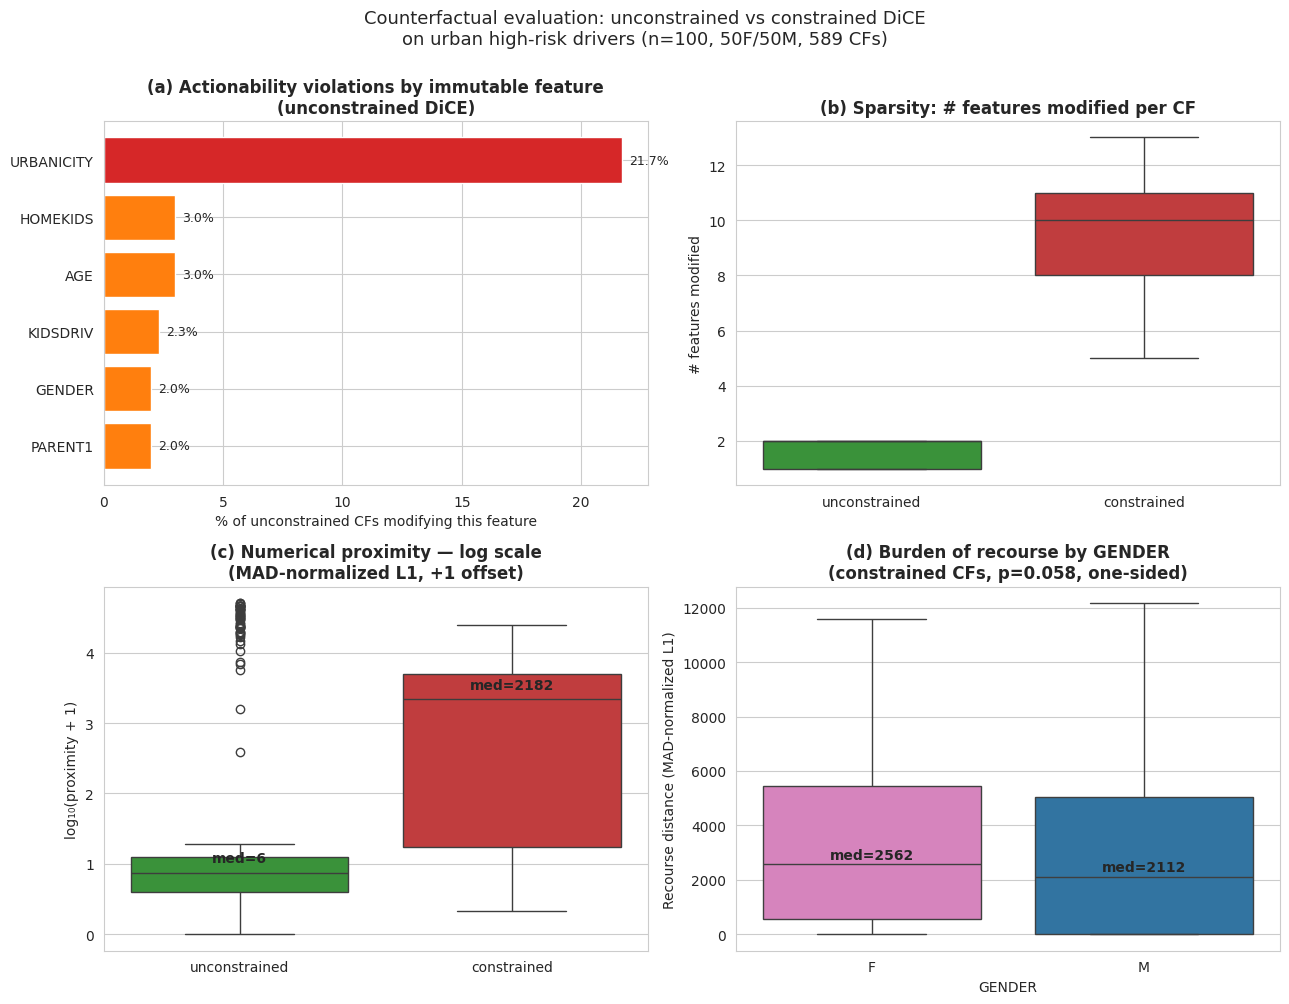


RÉCAP CHIFFRÉ
               Validity (%)  Sparsity  Proximity (med)  Violations (%)  CFs per indiv
unconstrained         100.0      1.70              6.5            29.3           3.00
constrained           100.0      9.43           2182.5             0.0           2.92


In [19]:
# ─── Test stat + figures finales ───
from scipy.stats import mannwhitneyu

# (A) Test stat sur le Burden (proximity numérique en constrained)
print("="*65)
print("TEST STATISTIQUE — Burden of Recourse (constrained, F vs M)")
print("="*65)

cons = metrics_df[metrics_df['method'] == 'constrained']
prox_F = cons[cons['gender'] == 'F']['proximity_num']
prox_M = cons[cons['gender'] == 'M']['proximity_num']

# Mann-Whitney U (non-paramétrique, robuste aux distributions skewed)
stat, pval = mannwhitneyu(prox_F, prox_M, alternative='greater')
print(f"\nMann-Whitney U (one-sided, F > M):")
print(f"  n_F = {len(prox_F)}, n_M = {len(prox_M)}")
print(f"  median F = {prox_F.median():.1f}")
print(f"  median M = {prox_M.median():.1f}")
print(f"  mean F   = {prox_F.mean():.1f}")
print(f"  mean M   = {prox_M.mean():.1f}")
print(f"  U statistic = {stat:.1f}")
print(f"  p-value     = {pval:.4f}")
print(f"  Interprétation : {'*** SIGNIFICATIF ***' if pval < 0.05 else 'non significatif au seuil 0.05'}")

# Effect size : Cohen's d sur rangs (approximation)
import numpy as np
r_effect = 1 - (2 * stat) / (len(prox_F) * len(prox_M))
print(f"  rank-biserial correlation = {r_effect:.3f}  (>0 = F has higher proximity)")



fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Violations
ax = axes[0, 0]
viol_data = pd.Series({
    'URBANICITY': 21.7, 'AGE': 3.0, 'HOMEKIDS': 3.0,
    'KIDSDRIV': 2.3, 'GENDER': 2.0, 'PARENT1': 2.0
}).sort_values()
colors = ['#d62728' if x > 5 else '#ff7f0e' for x in viol_data.values]
ax.barh(viol_data.index, viol_data.values, color=colors)
ax.set_xlabel('% of unconstrained CFs modifying this feature')
ax.set_title('(a) Actionability violations by immutable feature\n(unconstrained DiCE)',
             fontweight='bold')
for i, v in enumerate(viol_data.values):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# (b) Sparsity
ax = axes[0, 1]
sns.boxplot(data=metrics_df, x='method', y='sparsity', ax=ax,
            palette=['#2ca02c', '#d62728'], hue='method', legend=False)
ax.set_title('(b) Sparsity: # features modified per CF', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('# features modified')

# (c) Proximity in LOG SCALE — pour montrer le vrai trade-off
ax = axes[1, 0]
# Ajouter +1 pour éviter log(0)
metrics_df_plot = metrics_df.copy()
metrics_df_plot['proximity_log'] = np.log10(metrics_df_plot['proximity_num'] + 1)
sns.boxplot(data=metrics_df_plot, x='method', y='proximity_log', ax=ax,
            palette=['#2ca02c', '#d62728'], hue='method', legend=False)
ax.set_title('(c) Numerical proximity — log scale\n(MAD-normalized L1, +1 offset)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('log₁₀(proximity + 1)')
# Annoter les médianes en valeurs originales
for i, m in enumerate(['unconstrained', 'constrained']):
    med_orig = metrics_df[metrics_df['method']==m]['proximity_num'].median()
    med_log = np.log10(med_orig + 1)
    ax.text(i, med_log + 0.15, f'med={med_orig:.0f}',
            ha='center', fontsize=10, fontweight='bold')

# (d) Burden by gender
ax = axes[1, 1]
sns.boxplot(data=metrics_df[metrics_df['method']=='constrained'],
            x='gender', y='proximity_num', ax=ax,
            palette=['#e377c2', '#1f77b4'], hue='gender', legend=False,
            showfliers=False)
pval_global = sub_df[sub_df['subgroup']=='ALL (baseline)']['pval'].iloc[0]
ax.set_title(f'(d) Burden of recourse by GENDER\n(constrained CFs, p={pval_global:.3f}, one-sided)',
             fontweight='bold')
ax.set_xlabel('GENDER')
ax.set_ylabel('Recourse distance (MAD-normalized L1)')
for i, g in enumerate(['F', 'M']):
    med = metrics_df[(metrics_df['method']=='constrained') &
                     (metrics_df['gender']==g)]['proximity_num'].median()
    ax.text(i, med + 200, f'med={med:.0f}', ha='center',
            fontsize=10, fontweight='bold')

plt.suptitle('Counterfactual evaluation: unconstrained vs constrained DiCE\n'
             'on urban high-risk drivers (n=100, 50F/50M, 589 CFs)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('fig2_cf_results.png', dpi=150, bbox_inches='tight')
plt.show()


# ─── (C) Récap ─────────────────────
print("\n" + "="*65)
print("RÉCAP CHIFFRÉ")
print("="*65)
recap = pd.DataFrame({
    'Validity (%)':     [100.0, 100.0],
    'Sparsity':         [round(metrics_df[metrics_df.method=='unconstrained']['sparsity'].mean(), 2),
                         round(metrics_df[metrics_df.method=='constrained']['sparsity'].mean(), 2)],
    'Proximity (med)':  [round(metrics_df[metrics_df.method=='unconstrained']['proximity_num'].median(), 1),
                         round(metrics_df[metrics_df.method=='constrained']['proximity_num'].median(), 1)],
    'Violations (%)':   [29.3, 0.0],
    'CFs per indiv':    [3.00, 2.92],
}, index=['unconstrained', 'constrained'])
print(recap.to_string())

In [18]:
# ─── (A) Sous-groupes intersectionnels + (B) Fig (c) corrigée en log ───
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

# On enrichit metrics_df avec les caractéristiques du factual de chaque CF
metrics_with_factual = metrics_df.merge(
    factuals[['AGE', 'EDUCATION', 'MSTATUS']].reset_index().rename(
        columns={'index': 'candidate_id'}
    ),
    on='candidate_id'
)

# Sous-groupes à tester
def test_subgroup(df, label):
    """Test Mann-Whitney F > M sur la proximity numérique en constrained."""
    cons = df[df['method'] == 'constrained']
    F = cons[cons['gender'] == 'F']['proximity_num']
    M = cons[cons['gender'] == 'M']['proximity_num']
    if len(F) < 5 or len(M) < 5:
        return {'subgroup': label, 'n_F': len(F), 'n_M': len(M),
                'med_F': np.nan, 'med_M': np.nan, 'ratio': np.nan, 'pval': np.nan}
    stat, p = mannwhitneyu(F, M, alternative='greater')
    return {
        'subgroup': label,
        'n_F': len(F), 'n_M': len(M),
        'med_F': F.median(), 'med_M': M.median(),
        'ratio_F_over_M': F.median() / M.median() if M.median() > 0 else np.nan,
        'pval': p
    }

results_subgroups = []

# Découpage 1 : EDUCATION (Low = <HS, HS vs High = Bachelors+)
low_edu = metrics_with_factual['EDUCATION'].isin(['<High School', 'High School'])
results_subgroups.append(test_subgroup(metrics_with_factual[low_edu], 'EDUCATION = Low (<HS, HS)'))
results_subgroups.append(test_subgroup(metrics_with_factual[~low_edu], 'EDUCATION = High (Bach+)'))

# Découpage 2 : AGE
young = metrics_with_factual['AGE'] < 40
results_subgroups.append(test_subgroup(metrics_with_factual[young], 'AGE < 40'))
results_subgroups.append(test_subgroup(metrics_with_factual[~young], 'AGE >= 40'))

# Découpage 3 : MSTATUS
married = metrics_with_factual['MSTATUS'] == 'Yes'
results_subgroups.append(test_subgroup(metrics_with_factual[married], 'MSTATUS = Married'))
results_subgroups.append(test_subgroup(metrics_with_factual[~married], 'MSTATUS = Single'))

# Baseline rappel
results_subgroups.insert(0, test_subgroup(metrics_with_factual, 'ALL (baseline)'))

sub_df = pd.DataFrame(results_subgroups)
sub_df_display = sub_df.copy()
sub_df_display[['med_F', 'med_M', 'ratio_F_over_M', 'pval']] = sub_df_display[
    ['med_F', 'med_M', 'ratio_F_over_M', 'pval']
].round(3)

print("="*75)
print("INTERSECTIONAL BURDEN OF RECOURSE — F vs M across subgroups")
print("="*75)
print(sub_df_display.to_string(index=False))

# Marquer les significatifs
print("\nSignal interpretation :")
for _, row in sub_df.iterrows():
    if pd.isna(row['pval']):
        continue
    if row['pval'] < 0.01:
        flag = '*** STRONGLY SIGNIFICANT (p<0.01)'
    elif row['pval'] < 0.05:
        flag = '** SIGNIFICANT (p<0.05)'
    elif row['pval'] < 0.10:
        flag = '* trend (p<0.10)'
    else:
        flag = '   (no signal)'
    print(f"  {row['subgroup']:35s}  p={row['pval']:.3f}  {flag}")

INTERSECTIONAL BURDEN OF RECOURSE — F vs M across subgroups
                 subgroup  n_F  n_M    med_F    med_M  ratio_F_over_M  pval
           ALL (baseline)  145  147 2562.492 2112.211           1.213 0.058
EDUCATION = Low (<HS, HS)   92   94 1856.673 2177.422           0.853 0.187
 EDUCATION = High (Bach+)   53   53 2855.129 1682.444           1.697 0.070
                 AGE < 40   67   50 2515.647 2360.062           1.066 0.199
                AGE >= 40   78   97 2649.848 1694.870           1.563 0.057
        MSTATUS = Married   65   63 2207.054 1323.502           1.668 0.042
         MSTATUS = Single   80   84 2649.848 2735.400           0.969 0.330

Signal interpretation :
  ALL (baseline)                       p=0.058  * trend (p<0.10)
  EDUCATION = Low (<HS, HS)            p=0.187     (no signal)
  EDUCATION = High (Bach+)             p=0.070  * trend (p<0.10)
  AGE < 40                             p=0.199     (no signal)
  AGE >= 40                            p=0.057  * t

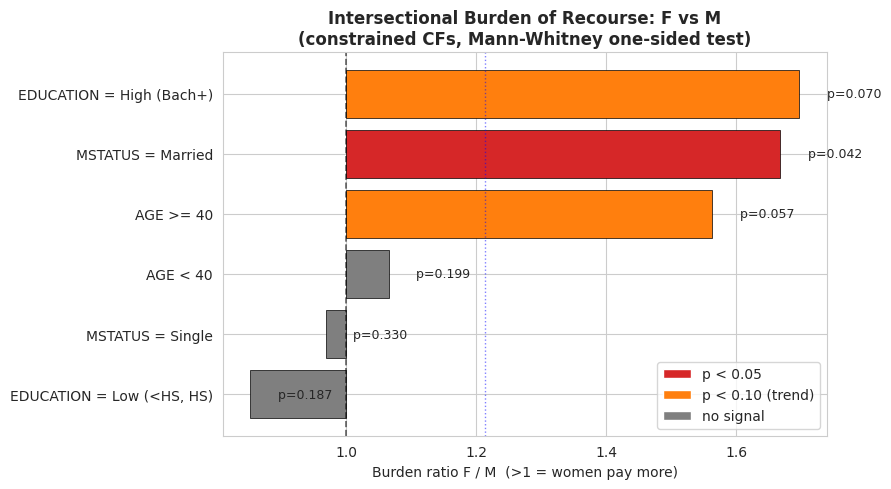

In [20]:
# ─── Figure 3 : Burden ratios par sous-groupe (forest plot style) ───
fig, ax = plt.subplots(figsize=(9, 5))

# Trier par ratio (excluant la baseline qu'on met à part)
sub_no_baseline = sub_df[sub_df['subgroup'] != 'ALL (baseline)'].copy()
sub_no_baseline = sub_no_baseline.sort_values('ratio_F_over_M')

# Couleurs selon significativité
def color_for_p(p):
    if p < 0.05: return '#d62728'  # rouge = significatif
    if p < 0.10: return '#ff7f0e'  # orange = trend
    return '#7f7f7f'                # gris = pas de signal

colors = [color_for_p(p) for p in sub_no_baseline['pval']]

y_pos = range(len(sub_no_baseline))
ax.barh(y_pos, sub_no_baseline['ratio_F_over_M'] - 1, left=1,
        color=colors, edgecolor='black', linewidth=0.5)

# Ligne de référence à ratio=1 (= pas d'écart F vs M)
ax.axvline(1, color='black', linewidth=1.2, linestyle='--', alpha=0.6)

# Annoter les p-values
for i, (_, row) in enumerate(sub_no_baseline.iterrows()):
    ax.text(row['ratio_F_over_M'] + 0.03, i,
            f"  p={row['pval']:.3f}", va='center', fontsize=9)

# Baseline en pointillé
baseline_ratio = sub_df[sub_df['subgroup']=='ALL (baseline)']['ratio_F_over_M'].iloc[0]
ax.axvline(baseline_ratio, color='blue', linewidth=1, linestyle=':',
           alpha=0.5, label=f'overall ratio = {baseline_ratio:.2f}')

ax.set_yticks(y_pos)
ax.set_yticklabels(sub_no_baseline['subgroup'])
ax.set_xlabel('Burden ratio F / M  (>1 = women pay more)')
ax.set_title('Intersectional Burden of Recourse: F vs M\n'
             '(constrained CFs, Mann-Whitney one-sided test)',
             fontweight='bold')

# Légende couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='p < 0.05'),
    Patch(facecolor='#ff7f0e', label='p < 0.10 (trend)'),
    Patch(facecolor='#7f7f7f', label='no signal'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig3_burden_subgroups.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ─── Sauvegarde des résultats sur Google Drive ───
import pickle, os

save_dir = root_path + 'cf_project_outputs/'
os.makedirs(save_dir, exist_ok=True)

artifacts = {
    'df_clean': df_clean,
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'fitted_pipelines': fitted_pipelines,
    'cf_results': cf_results,
    'factuals': factuals,
    'metrics_df': metrics_df,
    'metrics_with_factual': metrics_with_factual,
    'sub_df': sub_df,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'features_to_vary': features_to_vary,
    'permitted_range': permitted_range,
    'immutable_features': immutable_features,
    'mad_values': mad_values,
}

with open(save_dir + 'cf_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# Backup CSV des résultats principaux (plus lisible que pickle)
cf_results.to_csv(save_dir + 'cf_results.csv', index=False)
metrics_with_factual.to_csv(save_dir + 'metrics_per_cf.csv', index=False)
sub_df.to_csv(save_dir + 'fairness_subgroups.csv', index=False)

print(f"Sauvegardé dans : {save_dir}")
print(f"Fichiers : {os.listdir(save_dir)}")
print(f"\nPour recharger plus tard :")
print(f"  with open('{save_dir}cf_artifacts.pkl', 'rb') as f:")
print(f"      artifacts = pickle.load(f)")

Sauvegardé dans : /content/drive/MyDrive/cf_project_outputs/
Fichiers : ['cf_artifacts.pkl', 'cf_results.csv', 'metrics_per_cf.csv', 'fairness_subgroups.csv']

Pour recharger plus tard :
  with open('/content/drive/MyDrive/cf_project_outputs/cf_artifacts.pkl', 'rb') as f:
      artifacts = pickle.load(f)


CFs analysés : 65 F-married, 63 M-married

FRÉQUENCE DE MODIFICATION PAR FEATURE (mariés, CFs constrained)
   feature type  freq_modif_%_F  freq_modif_%_M  diff_freq
   CAR_USE  cat            13.8            52.4      -38.5
    INCOME  num            70.8            90.5      -19.7
   RED_CAR  cat             6.2            23.8      -17.7
  CLM_FREQ  num            43.1            28.6       14.5
 EDUCATION  cat            38.5            49.2      -10.7
       YOJ  num            64.6            73.0       -8.4
   REVOKED  cat             4.6            12.7       -8.1
  OLDCLAIM  num            73.8            66.7        7.2
   MSTATUS  cat             7.7            14.3       -6.6
   MVR_PTS  num            55.4            60.3       -4.9
  CAR_TYPE  cat            46.2            50.8       -4.6
  HOME_VAL  num            86.2            90.5       -4.3
   CAR_AGE  num            69.2            66.7        2.6
  TRAVTIME  num            98.5            96.8        1.6
  BLUEBO

/tmp/ipykernel_11869/2733111288.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])


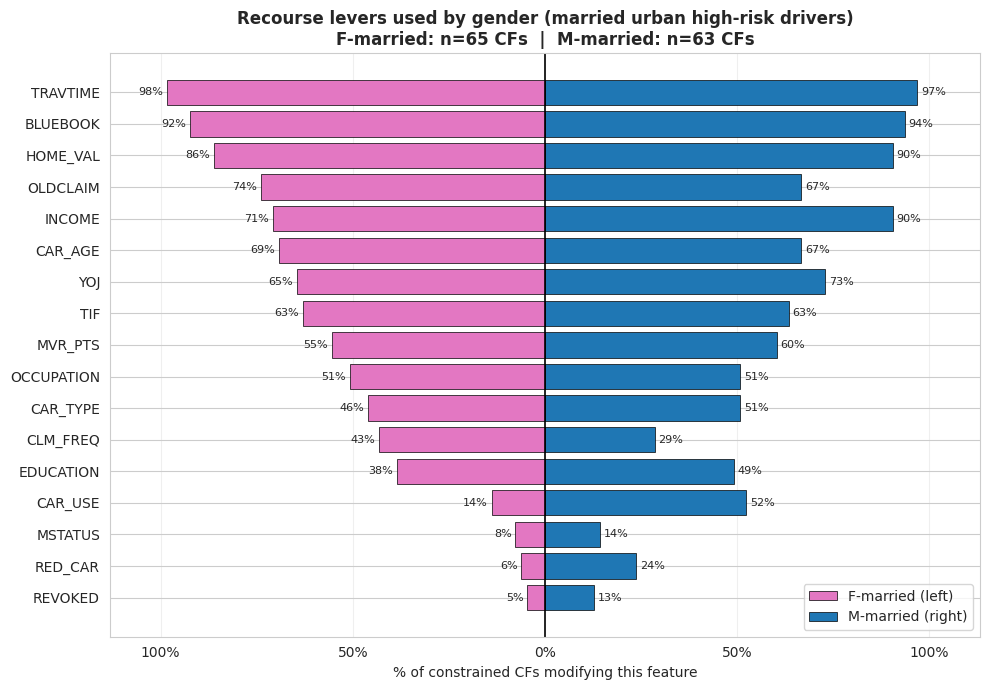


KEY NUMBERS FOR THE REPORT
Sample size: 22 F-married + 21 M-married candidates
             65 F CFs + 63 M CFs (constrained)

Median Burden (married): F = 2207, M = 1324
Ratio F/M (median): 1.67
Mean Burden (married):   F = 3909, M = 2499
Ratio F/M (mean): 1.56


In [23]:
# ─── Case study agrégé : CFs F-married vs M-married ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identifier les candidats mariés et leurs CFs constrained
married_factuals = factuals[factuals['MSTATUS'] == 'Yes']
married_F_ids = married_factuals[married_factuals['gender'] == 'F'].index
married_M_ids = married_factuals[married_factuals['gender'] == 'M'].index

cfs_married = cf_results[
    (cf_results['method'] == 'constrained') &
    (cf_results['candidate_id'].isin(married_factuals.index))
].copy()
# Ajouter MSTATUS info pour filtre (déjà filtré par candidate_id mais propre)
cfs_F_married = cfs_married[cfs_married['candidate_id'].isin(married_F_ids)]
cfs_M_married = cfs_married[cfs_married['candidate_id'].isin(married_M_ids)]

print(f"CFs analysés : {len(cfs_F_married)} F-married, {len(cfs_M_married)} M-married")

# 2. Fonction : pour chaque feature, % de CFs qui la modifient + ampleur moyenne
def modification_stats(cfs_df, factuals_df, num_cols, cat_cols):
    """Retourne un DF avec, par feature : freq_modif (%), ampleur moyenne signée."""
    rows = []
    for col in num_cols:
        changes = []
        for _, cf in cfs_df.iterrows():
            cid = cf['candidate_id']
            v_fact = factuals_df.loc[cid, col]
            delta = cf[col] - v_fact
            changes.append(delta)
        changes = np.array(changes)
        freq = (np.abs(changes) > 1e-6).mean() * 100
        # ampleur signée (mean delta quand modifié)
        modified_deltas = changes[np.abs(changes) > 1e-6]
        avg_delta = modified_deltas.mean() if len(modified_deltas) > 0 else 0.0
        rows.append({'feature': col, 'type': 'num',
                     'freq_modif_%': freq, 'avg_delta_when_modified': avg_delta})
    for col in cat_cols:
        changed_flags = []
        for _, cf in cfs_df.iterrows():
            cid = cf['candidate_id']
            v_fact = factuals_df.loc[cid, col]
            changed_flags.append(cf[col] != v_fact)
        freq = np.mean(changed_flags) * 100
        rows.append({'feature': col, 'type': 'cat',
                     'freq_modif_%': freq, 'avg_delta_when_modified': np.nan})
    return pd.DataFrame(rows)

stats_F = modification_stats(cfs_F_married, factuals, numerical_features, categorical_features)
stats_M = modification_stats(cfs_M_married, factuals, numerical_features, categorical_features)

# 3. Fusionner pour comparaison côte à côte
comp = stats_F.merge(stats_M, on=['feature', 'type'], suffixes=('_F', '_M'))
comp['diff_freq'] = comp['freq_modif_%_F'] - comp['freq_modif_%_M']
comp = comp.sort_values('diff_freq', key=abs, ascending=False)

print("\n" + "="*80)
print("FRÉQUENCE DE MODIFICATION PAR FEATURE (mariés, CFs constrained)")
print("="*80)
print(comp[['feature', 'type', 'freq_modif_%_F', 'freq_modif_%_M', 'diff_freq']]
      .round(1).to_string(index=False))

# 4. Top features avec la plus grande disparité F vs M
print("\n" + "="*80)
print("TOP DIFFÉRENCES F vs M (positif = plus modifié chez F)")
print("="*80)
top = comp.sort_values('diff_freq', ascending=False).head(8)[
    ['feature', 'freq_modif_%_F', 'freq_modif_%_M', 'diff_freq']
].round(1)
print(top.to_string(index=False))
print("\nBOTTOM (positif = plus modifié chez M):")
bot = comp.sort_values('diff_freq').head(8)[
    ['feature', 'freq_modif_%_F', 'freq_modif_%_M', 'diff_freq']
].round(1)
print(bot.to_string(index=False))

# 5. Figure : bar chart en miroir des features les plus modifiées
fig, ax = plt.subplots(figsize=(10, 7))

# Garder les features modifiées au moins par 1 des 2 groupes (>5%)
mask = (comp['freq_modif_%_F'] > 5) | (comp['freq_modif_%_M'] > 5)
plot_data = comp[mask].sort_values('freq_modif_%_F', ascending=True)

y_pos = np.arange(len(plot_data))
ax.barh(y_pos, -plot_data['freq_modif_%_F'], color='#e377c2',
        edgecolor='black', linewidth=0.5, label='F-married (left)')
ax.barh(y_pos,  plot_data['freq_modif_%_M'], color='#1f77b4',
        edgecolor='black', linewidth=0.5, label='M-married (right)')

# Ligne centrale
ax.axvline(0, color='black', linewidth=1.2)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['feature'])

# Axe x symétrique
max_val = max(plot_data['freq_modif_%_F'].max(), plot_data['freq_modif_%_M'].max())
ax.set_xlim(-max_val*1.15, max_val*1.15)

# Tick labels en valeur absolue
ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(int(t))}%' for t in ticks])

ax.set_xlabel('% of constrained CFs modifying this feature')
ax.set_title('Recourse levers used by gender (married urban high-risk drivers)\n'
             f'F-married: n={len(cfs_F_married)} CFs  |  M-married: n={len(cfs_M_married)} CFs',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Annoter les valeurs
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(-row['freq_modif_%_F'] - 1, i, f"{row['freq_modif_%_F']:.0f}%",
            ha='right', va='center', fontsize=8)
    ax.text(row['freq_modif_%_M'] + 1, i, f"{row['freq_modif_%_M']:.0f}%",
            ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_levers_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Récap chiffré pour le rapport
print("\n" + "="*80)
print("KEY NUMBERS FOR THE REPORT")
print("="*80)
n_F_cand = len(married_F_ids)
n_M_cand = len(married_M_ids)
print(f"Sample size: {n_F_cand} F-married + {n_M_cand} M-married candidates")
print(f"             {len(cfs_F_married)} F CFs + {len(cfs_M_married)} M CFs (constrained)")

# Median Burden pour le sous-groupe married, déjà calculé
mar_F_prox = metrics_with_factual[
    (metrics_with_factual['method']=='constrained') &
    (metrics_with_factual['gender']=='F') &
    (metrics_with_factual['MSTATUS']=='Yes')
]['proximity_num']
mar_M_prox = metrics_with_factual[
    (metrics_with_factual['method']=='constrained') &
    (metrics_with_factual['gender']=='M') &
    (metrics_with_factual['MSTATUS']=='Yes')
]['proximity_num']
print(f"\nMedian Burden (married): F = {mar_F_prox.median():.0f}, M = {mar_M_prox.median():.0f}")
print(f"Ratio F/M (median): {mar_F_prox.median()/mar_M_prox.median():.2f}")
print(f"Mean Burden (married):   F = {mar_F_prox.mean():.0f}, M = {mar_M_prox.mean():.0f}")
print(f"Ratio F/M (mean): {mar_F_prox.mean()/mar_M_prox.mean():.2f}")